<a href="https://colab.research.google.com/github/NidhiCN24/Festiva_Projects_10000053456345432365634/blob/main/House_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#House price predictor
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
#Creating my own dataset consisting of 15 rows and 3 input features
data = {
    'Size_sqft': [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2700, 3000, 3200, 3500, 3700, 4000, 4200],
    'Bedrooms': [2,2,3,3,3,4,4,4,5,5,5,6,6,6,7],
    'Age': [10,8,6,5,4,3,3,2,2,1,1,1,1,1,1],
    'Price_in_INR': [4000000,5000000,6000000,7500000,9000000,11000000,13000000,15000000,16500000,18000000,20000000,22000000,24000000,26000000,28000000]
}

#printing the dataset
df = pd.DataFrame(data)
df

,Size_sqft,Bedrooms,Age,Price_in_INR
0,800,2,10,4000000
1,1000,2,8,5000000
2,1200,3,6,6000000
3,1500,3,5,7500000
4,1800,3,4,9000000
5,2000,4,3,11000000
6,2200,4,3,13000000
7,2500,4,2,15000000
8,2700,5,2,16500000
9,3000,5,1,18000000


In [19]:
#printing first 5 rows, last 5 rows, shape and data types of attributes in the dataset
print("First 5 rows:\n", df.head())

print("\nLast 5 rows:\n", df.tail())

print("\nShape:", df.shape)

print("\nData Types:\n", df.dtypes)

print("\nMissing Values:\n", df.isnull().sum())

First 5 rows:
    Size_sqft  Bedrooms  Age  Price_in_INR
0        800         2   10       4000000
1       1000         2    8       5000000
2       1200         3    6       6000000
3       1500         3    5       7500000
4       1800         3    4       9000000

Last 5 rows:
     Size_sqft  Bedrooms  Age  Price_in_INR
10       3200         5    1      20000000
11       3500         6    1      22000000
12       3700         6    1      24000000
13       4000         6    1      26000000
14       4200         7    1      28000000

Shape: (15, 4)

Data Types:
 Size_sqft       int64
Bedrooms        int64
Age             int64
Price_in_INR    int64
dtype: object

Missing Values:
 Size_sqft       0
Bedrooms        0
Age             0
Price_in_INR    0
dtype: int64


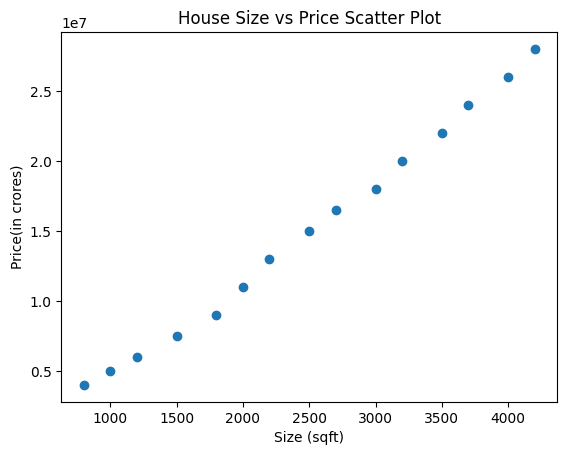

In [24]:
#plotting a scatter plot
plt.scatter(df['Size_sqft'], df['Price_in_INR'])
plt.title("House Size vs Price Scatter Plot")
plt.xlabel("Size (sqft)")
plt.ylabel("Price(in crores)")
plt.show()

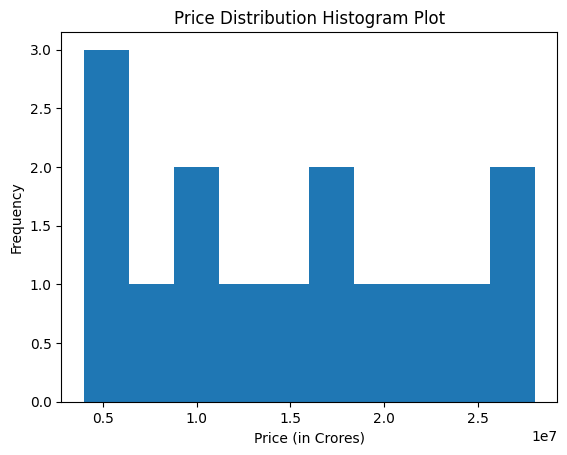

In [26]:
#Plotting  a histogram
plt.hist(df['Price_in_INR'])
plt.title("Price Distribution Histogram Plot")
plt.xlabel("Price (in Crores)")
plt.ylabel("Frequency")
plt.show()

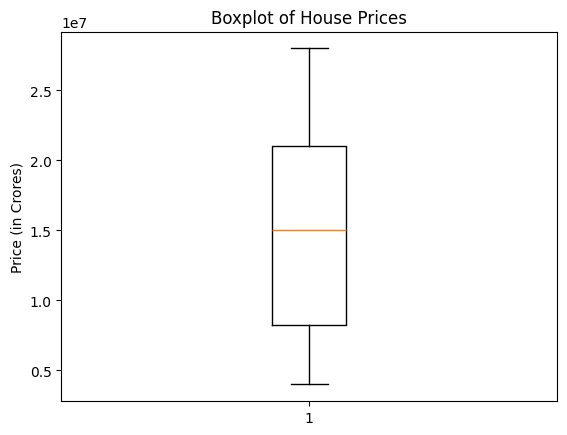

In [27]:
#Plotting a box plot
plt.boxplot(df['Price_in_INR'])
plt.title("Boxplot of House Prices")
plt.ylabel("Price (in Crores)")
plt.show()

In [32]:
#splitting dataset into training and testing data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Feature Engineering
df['Price_per_sqft'] = df['Price_in_INR'] / df['Size_sqft']

X = df[['Size_sqft', 'Bedrooms', 'Age', 'Price_per_sqft']]
y = df['Price_in_INR']

y_log = np.log(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred_log = model.predict(X_test)

# Convert back
y_pred = np.exp(y_pred_log)
y_test_actual = np.exp(y_test)

# Metrics
print("MAE:", mean_absolute_error(y_test_actual, y_pred))
print("R2 Score:", r2_score(y_test_actual, y_pred))

MAE: 285593.4730177
R2 Score: 0.997111764250202


In [33]:
print("""
Interpretation:
- MAE error value is in Lakhs, which is very less compared to crores of rupees of value we are encoutering in the price.
- R2 score is very high and close to one, which shows the model has learnt very well.
- Hence, here MAE value is low which is good.
- R2 score is as near to 1 which indicates high prediction accuracy
""")


Interpretation:
- MAE error value is in Lakhs, which is very less compared to crores of rupees of value we are encoutering in the price.
- R2 score is very high and close to one, which shows the model has learnt very well.
- Hence, here MAE value is low which is good.
- R2 score is as near to 1 which indicates high prediction accuracy



In [34]:
X_reduced = df[['Size_sqft', 'Bedrooms']]  # removed Age

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

model_r = LinearRegression()
model_r.fit(X_train_r, y_train_r)

y_pred_r = model_r.predict(X_test_r)

print("Reduced Features MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("Reduced Features R2:", r2_score(y_test_r, y_pred_r))

Reduced Features MAE: 869387.4516800459
Reduced Features R2: 0.9851179124762381


In [35]:
# New Feature: Price per Bedroom factor
df['Size_per_Bedroom'] = df['Size_sqft'] / df['Bedrooms']

X_new = df[['Size_sqft', 'Bedrooms', 'Age', 'Size_per_Bedroom']]

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y, test_size=0.2, random_state=42)

model_n = LinearRegression()
model_n.fit(X_train_n, y_train_n)

y_pred_n = model_n.predict(X_test_n)

print("New Feature MAE:", mean_absolute_error(y_test_n, y_pred_n))
print("New Feature R2:", r2_score(y_test_n, y_pred_n))

New Feature MAE: 273409.11242165975
New Feature R2: 0.9982259614455316


In [36]:
print("""
Comparison:
- Removing Age increased the MAE value significantly.
- Adding Size_per_Bedroom improves model understanding and accuracy.
- The feature that increases R2 the most is more important, so Size_per_Bedroom is most important.
""")


Comparison:
- Removing Age increased the MAE value significantly.
- Adding Size_per_Bedroom improves model understanding and accuracy.
- The feature that increases R2 the most is more important, so Size_per_Bedroom is most important.



In [37]:
model_full = LinearRegression()
model_full.fit(X, y)

y_full_pred = model_full.predict(X)

print("Full Data MAE:", mean_absolute_error(y, y_full_pred))
print("Full Data R2:", r2_score(y, y_full_pred))

Full Data MAE: 129711.89840100506
Full Data R2: 0.9996152067002809


In [38]:
print("""
Overfitting Check:
- Training on full dataset usually gives very high R2.
- This is not realistic for unseen data.
- Train-test split gives a better evaluation.
- Hence, it is always better to split data into train and test splits.
""")


Overfitting Check:
- Training on full dataset usually gives very high R2.
- This is not realistic for unseen data.
- Train-test split gives a better evaluation.
- Hence, it is always better to split data into train and test splits.

